# Week 5 - Maryi Tatiana Palacios Giraldo

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles=(8,8)):
        self.low = np.array(low)
        self.high = np.array(high)
        self.num_tilings = num_tilings
        self.tiles = np.array(tiles)
        self.tile_width = (self.high - self.low) / (self.tiles - 1)
        self.offsets = [i * self.tile_width / num_tilings for i in range(num_tilings)]
        self.feature_vector_len = num_tilings * tiles[0] * tiles[1]

    def get_features(self, state):
        features = np.zeros(self.feature_vector_len)
        position, velocity = state

        for i, offset in enumerate(self.offsets):
            shifted_state = np.array([position, velocity]) + offset
            ratios = (shifted_state - self.low) / self.tile_width
            indices = np.floor(ratios).astype(int)
            indices = np.clip(indices, 0, self.tiles - 1)

            tile_index = i * (self.tiles[0]*self.tiles[1]) + \
                         indices[0]*self.tiles[1] + indices[1]

            features[tile_index] = 1

        return features


# Semi-gradient SARSA

In [3]:
class SARSAAgent:
    def __init__(self, n_actions, feature_size, alpha=0.1, gamma=1.0, epsilon=0.1):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.weights = np.zeros((n_actions, feature_size))

    def q_value(self, features):
        return np.dot(self.weights, features)

    def select_action(self, features):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.q_value(features))

    def update(self, features, action, reward, next_features, next_action, done):
        q_current = np.dot(self.weights[action], features)
        q_next = 0 if done else np.dot(self.weights[next_action], next_features)

        target = reward + self.gamma * q_next
        delta = target - q_current

        self.weights[action] += self.alpha * delta * features

# Training

In [4]:
def train(env, tile_coder, agent, episodes=500):
    steps_per_episode = []

    for ep in range(episodes):
        state, _ = env.reset()
        features = tile_coder.get_features(state)
        action = agent.select_action(features)

        steps = 0
        done = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_features = tile_coder.get_features(next_state)
            next_action = agent.select_action(next_features)

            agent.update(features, action, reward, next_features, next_action, done)

            features = next_features
            action = next_action

            steps += 1

        steps_per_episode.append(steps)
        if ep % 50 == 0:
            print(f"Episode {ep}, Steps: {steps}")

    return steps_per_episode


# Visualization

In [5]:
def plot_learning_curve(steps):
    plt.plot(steps)
    plt.xlabel("Episode")
    plt.ylabel("Steps to Goal")
    plt.title("Learning Curve")
    plt.show()


def plot_value_function(tile_coder, agent):
    pos = np.linspace(-1.2, 0.6, 50)
    vel = np.linspace(-0.07, 0.07, 50)
    grid = np.zeros((50,50))

    for i,p in enumerate(pos):
        for j,v in enumerate(vel):
            features = tile_coder.get_features((p,v))
            grid[i,j] = np.max(agent.q_value(features))

    plt.imshow(grid, extent=[-1.2,0.6,-0.07,0.07], aspect='auto', origin='lower')
    plt.colorbar()
    plt.title("Value Function Heatmap")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.show()


In [11]:
def plot_policy(tile_coder, agent):
    pos = np.linspace(-1.2, 0.6, 50)
    vel = np.linspace(-0.07, 0.07, 50)
    policy = np.zeros((50,50))

    for i,p in enumerate(pos):
        for j,v in enumerate(vel):
            features = tile_coder.get_features((p,v))
            policy[i,j] = np.argmax(agent.q_value(features))

    plt.imshow(policy, extent=[-1.2,0.6,-0.07,0.07], aspect='auto', origin='lower')
    plt.colorbar()
    plt.title("Learned Policy")
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.show()

# Main

Episode 0, Steps: 200
Episode 50, Steps: 200
Episode 100, Steps: 200
Episode 150, Steps: 200
Episode 200, Steps: 161
Episode 250, Steps: 159
Episode 300, Steps: 200
Episode 350, Steps: 200
Episode 400, Steps: 148
Episode 450, Steps: 152


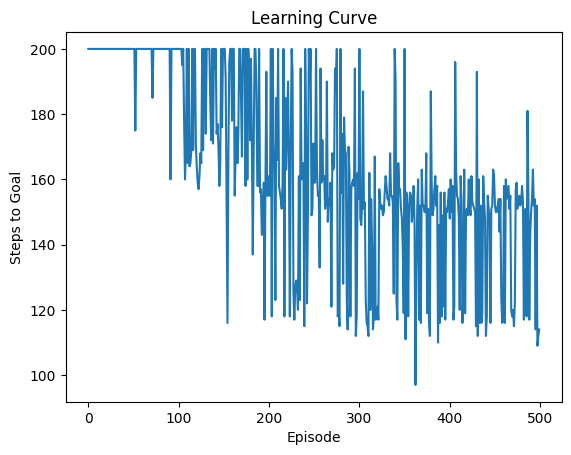

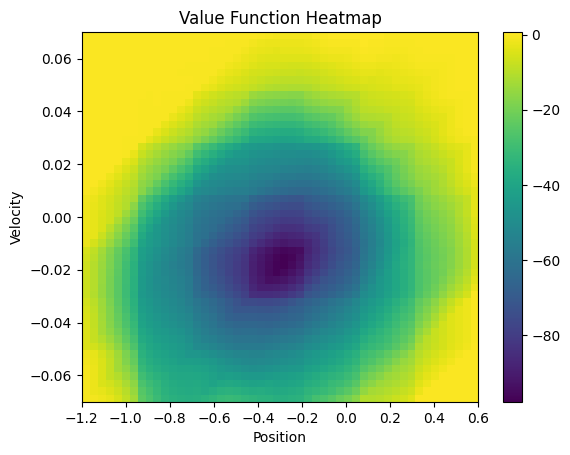

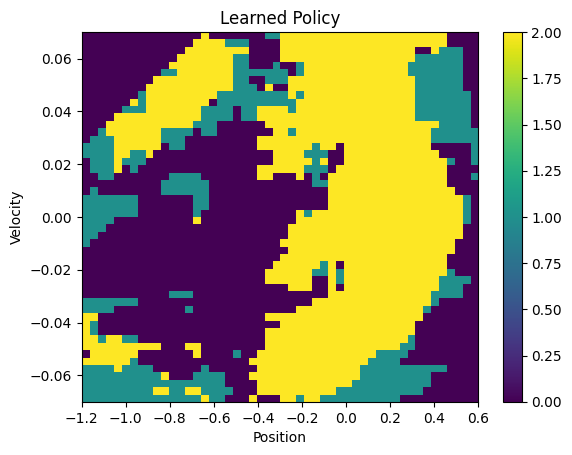

Episode 0, Steps: 200
Episode 50, Steps: 200
Episode 100, Steps: 200
Episode 150, Steps: 200
Episode 200, Steps: 154
Episode 250, Steps: 200
Episode 300, Steps: 158
Episode 350, Steps: 191
Episode 400, Steps: 150
Episode 450, Steps: 144


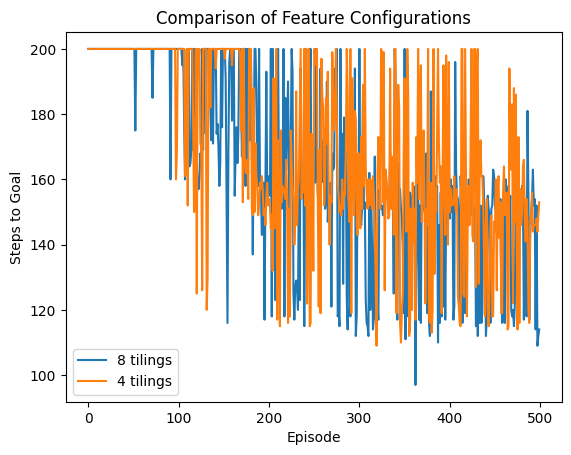

In [13]:
if __name__ == "__main__":
    env = gym.make("MountainCar-v0")

    tile_coder = TileCoder(low=[-1.2,-0.07], high=[0.6,0.07], num_tilings=8, tiles=(8,8))

    agent = SARSAAgent(n_actions=env.action_space.n,
                       feature_size=tile_coder.feature_vector_len,
                       alpha=0.1/8,
                       gamma=1.0,
                       epsilon=0.1)

    steps = train(env, tile_coder, agent, episodes=500)

    plot_learning_curve(steps)
    plot_value_function(tile_coder, agent)
    plot_policy(tile_coder, agent)  

    tile_coder_4 = TileCoder(low=[-1.2,-0.07], high=[0.6,0.07], num_tilings=4, tiles=(8,8))

    agent_4 = SARSAAgent(n_actions=env.action_space.n,
                         feature_size=tile_coder_4.feature_vector_len,
                         alpha=0.1/4,
                         gamma=1.0,
                         epsilon=0.1)

    steps_4 = train(env, tile_coder_4, agent_4, episodes=500)

    plt.plot(steps, label="8 tilings")
    plt.plot(steps_4, label="4 tilings")
    plt.legend()
    plt.title("Comparison of Feature Configurations")
    plt.xlabel("Episode")
    plt.ylabel("Steps to Goal")
    plt.show()

## Conclusion

This project demonstrated the importance of transitioning from tabular reinforcement learning methods to function approximation when dealing with continuous state spaces. In the MountainCar environment, a tabular approach is not feasible due to the infinite number of possible states defined by position and velocity. By implementing tile coding, the continuous space was effectively transformed into a structured feature representation that enabled generalization across similar states.

The use of semi-gradient SARSA allowed the agent to learn an action-value function through incremental updates based on observed transitions. Over time, the agent improved its policy by learning how to build momentum, which is essential for solving the MountainCar problem. The learning curve reflected this progression, showing a reduction in the number of steps required to reach the goal as training advanced.

A key insight from this project is the impact of feature design on learning performance. Increasing the number of tilings improved the agent’s ability to approximate the value function more accurately, leading to faster and more stable learning. However, this also introduced a trade-off in computational cost, as more features require more updates and memory. This highlights the importance of balancing representation quality and efficiency when designing function approximation methods.

Additionally, this lab reinforced the conceptual understanding of how semi-gradient methods operate. Unlike full gradient methods, semi-gradient approaches approximate the update by treating the target as fixed, which can introduce instability. This connects to the broader concept of the “deadly triad” in reinforcement learning, where the combination of function approximation, bootstrapping, and off-policy learning can lead to divergence. Although SARSA is on-policy and therefore more stable, this project illustrates how careful implementation is still required to ensure convergence.

Overall, this assignment provided practical experience in scaling reinforcement learning algorithms to more complex environments. It highlighted how function approximation, even in its simplest linear form, can enable effective learning in problems that would otherwise be intractable with tabular methods. The results emphasize that success in reinforcement learning depends not only on the algorithm itself, but also on how the state space is represented and how learning dynamics are managed.